In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd drive/MyDrive/data/behavior

/content/drive/MyDrive/data/behavior


In [ ]:
from sklearn.svm import OneClassSVM
import pandas as pd
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import numpy as np
from matplotlib import pyplot as plt
from numpy import quantile, where, random
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
df = pd.read_csv('training_sample.csv')
print(df.shape)

(455401, 25)


In [ ]:
df4.head().T

,6,11,19,22,24
UserID,7775-6b73b976-7775-4324-b1d9-622031,8976-6b747629-8976-4926-9cb2-715368,97c0-6b7645b3-97c0-4657-8ca8-978551,362d-6b7701e8-362d-4648-a171-128974,547b-6b773565-547b-4a8a-a7b6-309182
basket_icon_click,0,0,0,0,0
basket_add_list,0,0,0,0,0
basket_add_detail,0,0,0,0,0
sort_by,0,0,0,0,1
image_picker,0,0,0,0,0
account_page_click,0,0,0,0,0
promo_banner_click,0,0,0,0,0
detail_wishlist_add,0,0,0,0,0
list_size_dropdown,1,0,0,0,0


In [ ]:
data = df4[['basket_add_list' , 'basket_add_detail' , 'ordered' , 'basket_icon_click']].copy()

In [ ]:
data.head().T

,6,11,19,22,24
basket_add_list,0,0,0,0,0
basket_add_detail,0,0,0,0,0
ordered,0,0,0,0,0
basket_icon_click,0,0,0,0,0


In [ ]:
df4 = df[df.device_computer != 0]
df4.head().T
print(df4.shape)

(88448, 25)


In [ ]:
data_tmp = df.copy()
data_tmp['target'] = np.where(((data_tmp['basket_icon_click'] == 0) & (data_tmp['ordered'] == 0) & (data_tmp['device_computer'] == 1)), True, False)
item_counts = data_tmp["target"].value_counts()
print(item_counts)

False    377792
True      77609
Name: target, dtype: int64


In [ ]:
data['target'] = np.where(((data['basket_icon_click'] == 0) & (data['ordered'] == 1)), True, False)
item_counts = data["target"].value_counts()
print(item_counts)

False    86284
True      2164
Name: target, dtype: int64


In [ ]:
data_full_wo_T = data[['ordered' , 'basket_icon_click']].copy()
data_full_wo_T.head().T

,6,11,19,22,24
ordered,0,0,0,0,0
basket_icon_click,0,0,0,0,0


In [ ]:
data["target"].value_counts()

False    86284
True      2164
Name: target, dtype: int64

In [ ]:
data_2 = data.drop(data[data['target'] == True].index, inplace = False)
data_2.head().T

,6,11,19,22,24
basket_add_list,0,0,0,0,0
basket_add_detail,0,0,0,0,0
ordered,0,0,0,0,0
basket_icon_click,0,0,0,0,0
target,False,False,False,False,False


In [ ]:
data_2_wo_T = data_2[['ordered' , 'basket_icon_click']].copy()
data_2_wo_T.head().T

,6,11,19,22,24
ordered,0,0,0,0,0
basket_icon_click,0,0,0,0,0


In [ ]:
data.head().T

,6,11,19,22,24
basket_add_list,0,0,0,0,0
basket_add_detail,0,0,0,0,0
device_computer,1,1,1,1,1
ordered,0,0,0,0,0
basket_icon_click,0,0,0,0,0
target,False,False,False,False,False


In [ ]:
data_1= data[['ordered', 'basket_icon_click']].copy()

In [ ]:
item_counts = data["target"].value_counts()
print(item_counts)

False    86284
True      2164
Name: target, dtype: Int64


In [ ]:
# import libraries
import pandas as pd
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from numpy import where

In [ ]:
model = OneClassSVM(kernel='rbf', gamma=0.001, nu=0.01).fit(data_2_wo_T)

In [ ]:
y_pred = model.predict(data_full_wo_T)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
anomaly_val =data_full_wo_T.iloc[np.where(y_pred == -1)]
print (anomaly_val)

        ordered  basket_icon_click
165           1                  0
554           1                  0
592           1                  0
900           1                  0
1009          1                  0
...         ...                ...
454508        1                  0
454985        1                  0
455074        1                  0
455108        1                  0
455320        1                  0

[2164 rows x 2 columns]


In [ ]:
Target_T =y_pred[np.where(data['target'] == True)]
print (Target_T)

[-1 -1 -1 ... -1 -1 -1]


In [ ]:
acc = np.sum(Target_T == -1)/len(Target_T)
print(acc)

1.0


Text(0, 0.5, 'basket_icon_click')

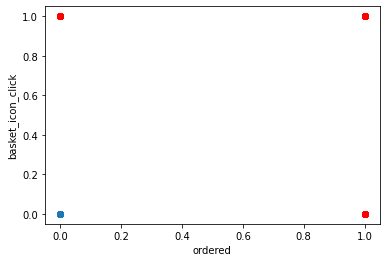

In [ ]:
plt.scatter(data_full_wo_T['ordered'],data_full_wo_T['basket_icon_click'])
plt.scatter(anomaly_val['ordered'], anomaly_val['basket_icon_click'], c="r")
plt.xlabel('ordered')
plt.ylabel('basket_icon_click')

In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn import tree
from sklearn.metrics import accuracy_score,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = 'data.csv'
df = pd.read_csv(data)
df.head()

,Unnamed: 0,basket_add_list,basket_add_detail,device_computer,ordered,basket_icon_click,target
0,6,0,0,1,0,0,False
1,11,0,0,1,0,0,False
2,19,0,0,1,0,0,False
3,22,0,0,1,0,0,False
4,24,0,0,1,0,0,False


In [ ]:
X = df.drop(columns=['target'])
y = df['target']
print(X.shape)
print(y.shape)

(88448, 6)
(88448,)


# Splitting dataset to train and test

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size = 0.20)
print(x_train.shape)
print(x_test.shape)

In [ ]:
# First we will fit a normal decision tree without any fine tuning and check the results

clf = tree.DecisionTreeClassifier(criterion="entropy")
clf.fit(x_train,y_train)
y_train_pred = clf.predict(x_train)
y_test_pred = clf.predict(x_test)


In [6]:
plt.figure(figsize=(20,20))
features = df.columns
classes = ['ordered','Not_ordered']
tree.plot_tree(clf,feature_names=features,class_names=classes,filled=True)
plt.show()

NameError: ignored

In [ ]:
# helper function
def plot_confusionmatrix(y_train_pred,y_train,dom):
    print(f'{dom} Confusion matrix')
    cf = confusion_matrix(y_train_pred,y_train)
    sns.heatmap(cf,annot=True,yticklabels=classes
               ,xticklabels=classes,cmap='Blues', fmt='g')
    plt.tight_layout()
    plt.show()

Train score 1.0
Test score 1.0
Train Confusion matrix


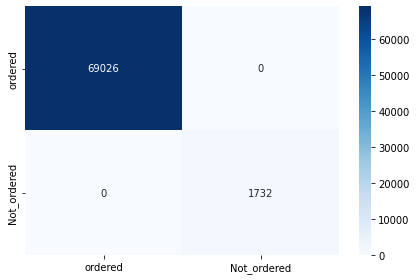

Test Confusion matrix


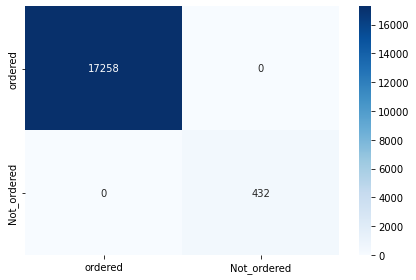

In [ ]:
print(f'Train score {accuracy_score(y_train_pred,y_train)}')
print(f'Test score {accuracy_score(y_test_pred,y_test)}')
plot_confusionmatrix(y_train_pred,y_train,dom='Train')
plot_confusionmatrix(y_test_pred,y_test,dom='Test')

In [ ]:
params = {'max_depth': [2,4,6,8,10,12],
         'min_samples_split': [2,3,4],
         'min_samples_leaf': [1,2]}

clf = tree.DecisionTreeClassifier()
gcv = GridSearchCV(estimator=clf,param_grid=params)
gcv.fit(x_train,y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 6, 8, 10, 12],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3, 4]})

Train score 1.0
Test score 1.0
Train Confusion matrix


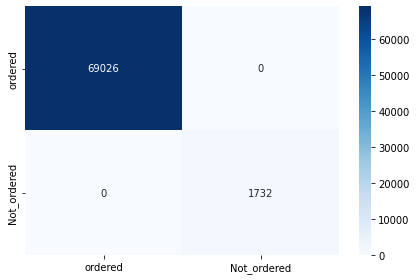

Test Confusion matrix


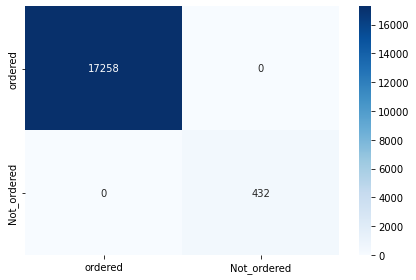

In [ ]:
model = gcv.best_estimator_
model.fit(x_train,y_train)
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

print(f'Train score {accuracy_score(y_train_pred,y_train)}')
print(f'Test score {accuracy_score(y_test_pred,y_test)}')
plot_confusionmatrix(y_train_pred,y_train,dom='Train')
plot_confusionmatrix(y_test_pred,y_test,dom='Test')

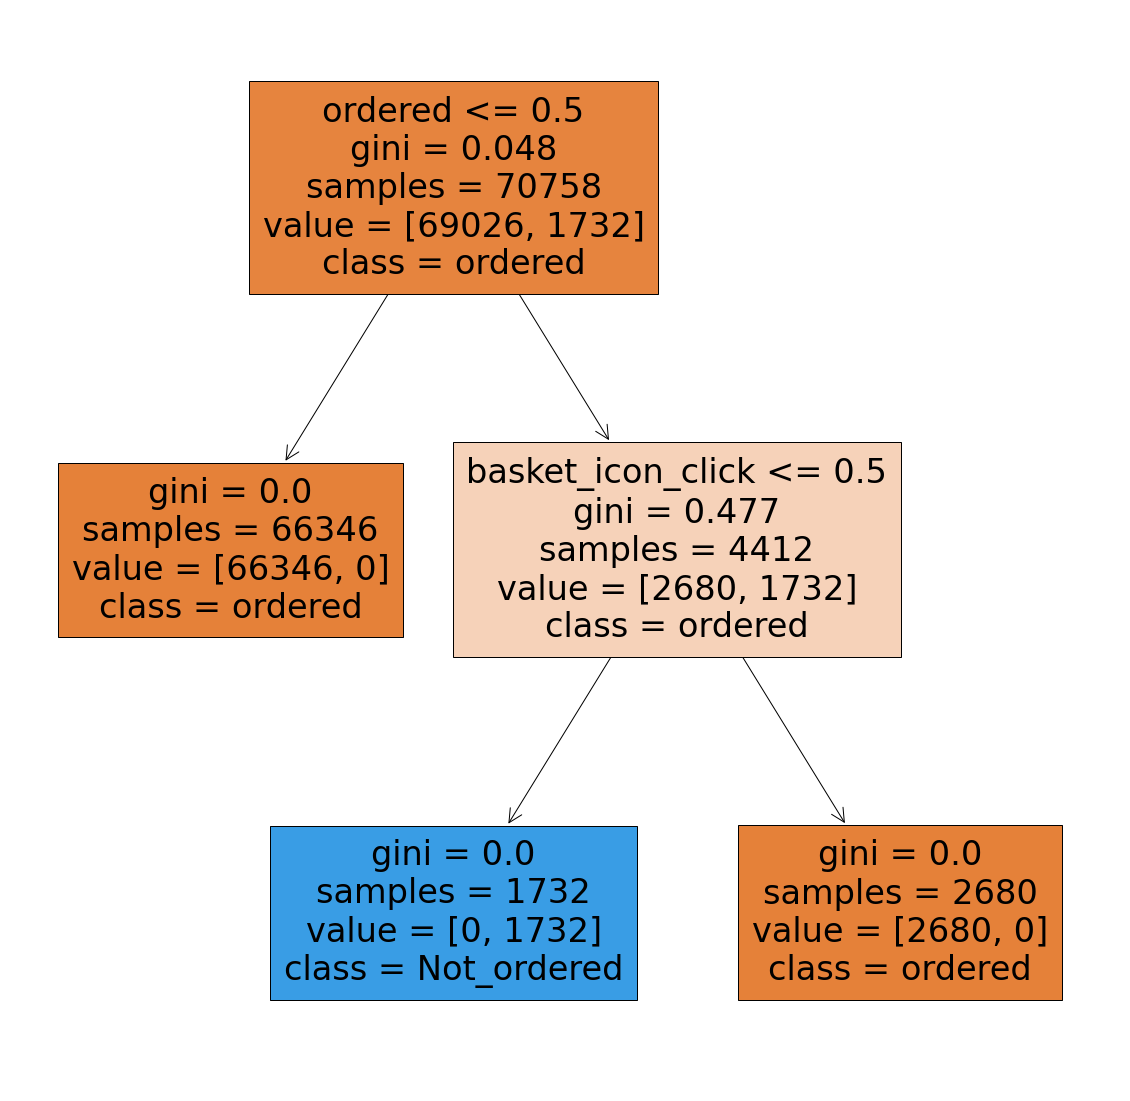

In [ ]:
plt.figure(figsize=(20,20))
features = df.columns
classes = ['ordered','Not_ordered']
tree.plot_tree(model,feature_names=features,class_names=classes,filled=True)
plt.show()

In [ ]:
# get the text representation
text_representation = tree.export_text(clf)
print(text_representation)

|--- feature_4 <= 0.50
|   |--- class: False
|--- feature_4 >  0.50
|   |--- feature_5 <= 0.50
|   |   |--- class: True
|   |--- feature_5 >  0.50
|   |   |--- class: False



In [ ]:
from sklearn.tree import _tree

def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []
    path = []
    
    def recurse(node, path, paths):
        
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            p1, p2 = list(path), list(path)
            p1 += [f"({name} <= {np.round(threshold, 3)})"]
            recurse(tree_.children_left[node], p1, paths)
            p2 += [f"({name} > {np.round(threshold, 3)})"]
            recurse(tree_.children_right[node], p2, paths)
        else:
            path += [(tree_.value[node], tree_.n_node_samples[node])]
            paths += [path]
            
    recurse(0, path, paths)

    # sort by samples count
    samples_count = [p[-1][1] for p in paths]
    ii = list(np.argsort(samples_count))
    paths = [paths[i] for i in reversed(ii)]
    
    rules = []
    for path in paths:
        rule = "if "
        
        for p in path[:-1]:
            if rule != "if ":
                rule += " and "
            rule += str(p)
        rule += " then "
        if class_names is None:
            rule += "response: "+str(np.round(path[-1][0][0][0],3))
        else:
            classes = path[-1][0][0]
            l = np.argmax(classes)
            rule += f"class: {class_names[l]} (proba: {np.round(100.0*classes[l]/np.sum(classes),2)}%)"
        rule += f" | based on {path[-1][1]:,} samples"
        rules += [rule]
        
    return rules

In [ ]:
features = df.columns
classes = ['ordered','Not_ordered']
rules = get_rules(clf, features, classes)
for r in rules:
    print(r)

if (ordered <= 0.5) then class: ordered (proba: 100.0%) | based on 66,346 samples
if (ordered > 0.5) and (basket_icon_click > 0.5) then class: ordered (proba: 100.0%) | based on 2,680 samples
if (ordered > 0.5) and (basket_icon_click <= 0.5) then class: Not_ordered (proba: 100.0%) | based on 1,732 samples
